<h1><font color='blue'>Análise de Sentimentos e Sistemas de Recomendação</font></h1>
<h2><b>Prática U1-T2-V3.2-Abordagens baseadas em machine learning</b></h2>


---

## Preparação

### Carregando o dataset

In [ ]:
import pandas as pd
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1M7VtNfEh7K3gqa4OiWiayPkg8q6x8fXk', encoding='utf-8', low_memory=False)
df.head()

,frase_pt,frase_en,sentimento
0,O atendimento ao cliente foi excepcional e res...,The customer service was exceptional and solve...,Positivo
1,"Este é, sem dúvida, o melhor café que já prove...","This is, without a doubt, the best coffee I've...",Positivo
2,O filme tem uma fotografia incrível e uma tril...,The movie has incredible cinematography and a ...,Positivo
3,Estou muito satisfeito com a qualidade do prod...,I am very satisfied with the product's quality...,Positivo
4,A equipe foi extremamente simpática e prestati...,The staff was extremely friendly and helpful t...,Positivo


In [ ]:
df['sentimento'].value_counts()

,count
sentimento,
Positivo,10
Negativo,10
Neutro,10


### Pré-processamento do texto

In [ ]:
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [ ]:
import re
from nltk.tokenize import word_tokenize
import unicodedata

def preprocess(text):
    text = text.lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    return tokens

preprocess('O trânsito      HOJE estava    $$$ %  &  #simplesmente insuportável.')

['o', 'transito', 'hoje', 'estava', 'simplesmente', 'insuportavel']

## Abordagem baseada em *Machine Learning*

O pipeline típico de machine learning tradicional para análise de sentimentos segue estas etapas principais:

1. **Representação Numérica do Texto**: O primeiro desafio é converter texto (dados não estruturados) em números (dados estruturados). Isso é feito através de técnicas de vetorização como Bag of Words (BoW), TF-IDF (Term Frequency-Inverse Document Frequency), ou n-gramas. Cada documento é representado como um vetor numérico onde cada posição corresponde a uma palavra específica do vocabulário, e o valor indica a importância ou frequência dessa palavra no documento.

2. **Engenharia de Features**: Além das palavras, podem ser extraídas características adicionais como comprimento do texto, presença de pontuação, número de maiúsculas, polaridade de palavras individuais (usando léxicos), entre outras. Estas features ajudam o algoritmo a capturar padrões mais sutis nos dados.

3. **Treinamento Supervisionado**: Os algoritmos aprendem padrões nos dados de treino rotulados, onde cada exemplo tem uma classe conhecida (positivo, negativo, neutro). O algoritmo identifica quais combinações de palavras e features estão associadas a cada classe de sentimento.

4. **Classificação**: Para novos textos, o modelo usa os padrões aprendidos para prever a classe mais provável, frequentemente fornecendo também uma medida de confiança na predição.


## Representação usando Bag-of-Words

### Separar as frases para treino (80%) e teste (20%)

Vamos utilizar 80% das frases de exemplo, para as quais já se conhece o sentimento, para treinar o modelo classificador baseado em *machine learning*.

Os 20% dos dados restantes serão utilizados para avaliar o desempenho do modelo treinado.

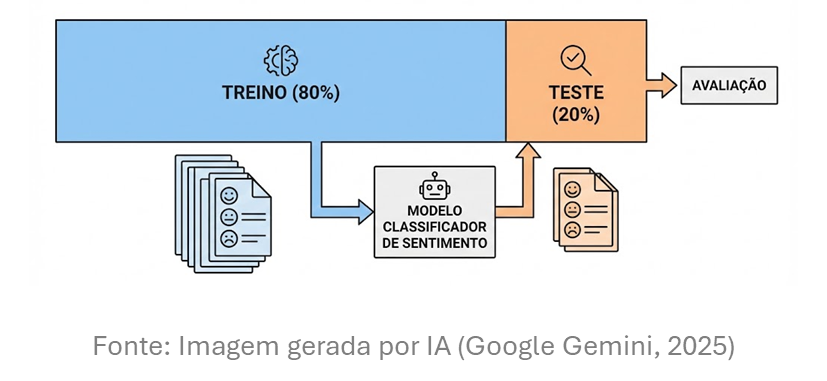

In [ ]:
X = df['frase_pt'].values.tolist()
y = df['sentimento'].values.tolist()

X[:10]

['O atendimento ao cliente foi excepcional e resolveu meu problema rapidamente.',
 'Este é, sem dúvida, o melhor café que já provei na cidade!',
 'O filme tem uma fotografia incrível e uma trilha sonora emocionante.',
 'Estou muito satisfeito com a qualidade do produto, superou minhas expectativas.',
 'A equipe foi extremamente simpática e prestativa durante toda a minha visita.',
 'Que experiência maravilhosa! Com certeza voltarei mais vezes.',
 'O livro chegou em perfeito estado e antes do prazo. Recomendo!',
 'A vista do quarto do hotel é absolutamente deslumbrante.',
 'Adorei a nova funcionalidade do aplicativo, ficou muito mais fácil de usar.',
 'O show foi espetacular, uma energia contagiante do início ao fim.']

In [ ]:
y[:10]

['Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo',
 'Positivo']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train[:10]

['A entrega foi feita no endereço combinado, conforme o pedido.',
 'A cor do carro é cinza e ele tem quatro portas.',
 'A comida estava fria e o garçom demorou uma eternidade para nos atender.',
 'O atendimento ao cliente foi excepcional e resolveu meu problema rapidamente.',
 'A equipe foi extremamente simpática e prestativa durante toda a minha visita.',
 'Péssima experiência de compra, o site é confuso e o suporte não ajuda.',
 'Que experiência maravilhosa! Com certeza voltarei mais vezes.',
 'Que filme terrível, o roteiro é fraco e as atuações são péssimas.',
 'Estou profundamente decepcionado com o serviço prestado, não recomendo.',
 'O voo de Belo Horizonte para São Paulo tem duração de aproximadamente uma hora.']

In [ ]:
y_train[:10]

['Neutro',
 'Neutro',
 'Negativo',
 'Positivo',
 'Positivo',
 'Negativo',
 'Positivo',
 'Negativo',
 'Negativo',
 'Neutro']

### Convertendo as frases para a representação vetorial (CountVectorizer)

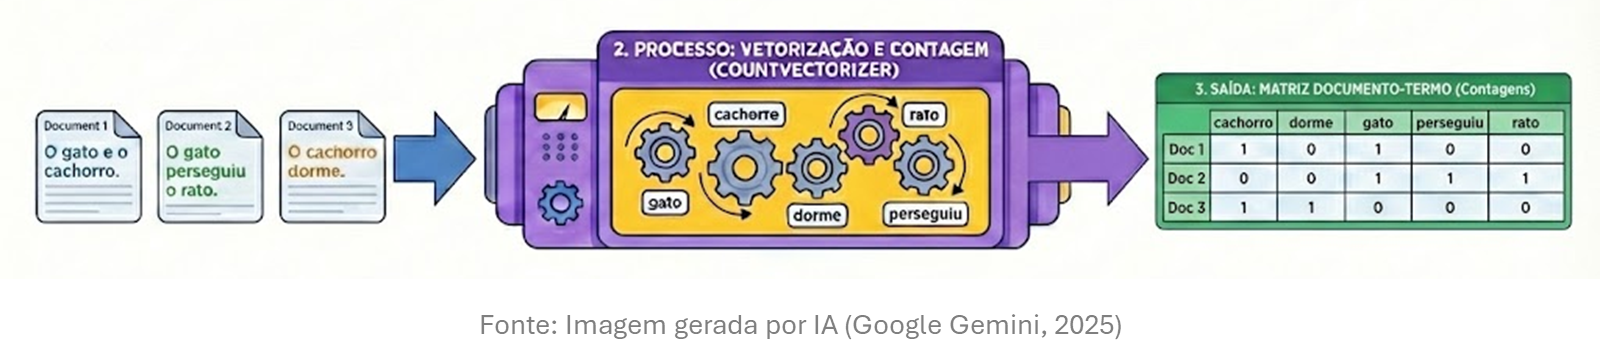

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vetor = CountVectorizer(lowercase=True, ngram_range=(1, 1))
vetor.fit(X)

X_train_vetor = vetor.transform(X_train)
X_test_vetor = vetor.transform(X_test)

pd.DataFrame(X_train_vetor.toarray(), columns=vetor.get_feature_names_out()).head(10)

,1985,19h,absolutamente,acessar,achei,adaptação,adorei,agendado,ajuda,amassada,...,uma,usar,uso,usuário,vezes,visita,vista,voltarei,voo,às
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0


### Treinar o modelo classificador

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vetor, y_train)


LogisticRegression(max_iter=1000, random_state=42)

### Testar o modelo em novos dados

Converter o texto para a representação vetorial numérica

In [ ]:
X_new = vetor.transform(['O atendimento ao cliente foi excepcional e resolveu meu problema rapidamente.'])
pd.DataFrame(X_new.toarray(), columns=vetor.get_feature_names_out()).head(10)

,1985,19h,absolutamente,acessar,achei,adaptação,adorei,agendado,ajuda,amassada,...,uma,usar,uso,usuário,vezes,visita,vista,voltarei,voo,às
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
model.predict(X_new)

array(['Positivo'], dtype='<U8')

### Avaliar modelo no conjunto de testes

In [ ]:
pd.DataFrame(X_test_vetor.toarray(), columns=vetor.get_feature_names_out()).head(10)

,1985,19h,absolutamente,acessar,achei,adaptação,adorei,agendado,ajuda,amassada,...,uma,usar,uso,usuário,vezes,visita,vista,voltarei,voo,às
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
y_test

['Neutro', 'Negativo', 'Neutro', 'Negativo', 'Positivo', 'Positivo']

In [ ]:
y_pred = model.predict(X_test_vetor)
y_pred.tolist()

['Positivo', 'Positivo', 'Positivo', 'Negativo', 'Positivo', 'Positivo']

In [ ]:
for frase, sentimento, predito in zip(X_test,y_test,y_pred):
    print(f'Frase: {frase:<80} - Sentimento: pred "{predito}" - real "{sentimento}"')


Frase: A bateria do celular dura o dia todo com uso moderado.                           - Sentimento: pred "Positivo" - real "Neutro"
Frase: Não gostei do final da série, achei que estragou toda a história.                - Sentimento: pred "Positivo" - real "Negativo"
Frase: Este documento contém as especificações técnicas do produto.                     - Sentimento: pred "Positivo" - real "Neutro"
Frase: O trânsito hoje estava simplesmente insuportável.                                - Sentimento: pred "Negativo" - real "Negativo"
Frase: Adorei a nova funcionalidade do aplicativo, ficou muito mais fácil de usar.      - Sentimento: pred "Positivo" - real "Positivo"
Frase: O show foi espetacular, uma energia contagiante do início ao fim.                - Sentimento: pred "Positivo" - real "Positivo"


Ver a taxa de acerto (acurácia)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.5

### Experimentar outros algoritmos classificadores

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=0)
}

resultados = {}

# Treinar e avaliar cada modelo
for nome, clf in modelos.items():
    clf.fit(X_train_vetor, y_train)
    y_pred = clf.predict(X_test_vetor)
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc

for modelo, acc in resultados.items():
    print(f"{modelo}: {acc:.2f}")

Naive Bayes: 0.33
Logistic Regression: 0.50
Linear SVM: 0.67
Decision Tree: 0.33
Random Forest: 0.50


In [ ]:
clf = LinearSVC()
clf.fit(X_train_vetor, y_train)
y_pred = clf.predict(X_test_vetor)
print(f'Taxa de acerto: {accuracy_score(y_test, y_pred)}\n')

for frase, sentimento, predito in zip(X_test,y_test,y_pred):
    print(f'Frase: {frase:<80} - Sentimento: pred "{predito}" - real "{sentimento}"')

Taxa de acerto: 0.6666666666666666

Frase: A bateria do celular dura o dia todo com uso moderado.                           - Sentimento: pred "Positivo" - real "Neutro"
Frase: Não gostei do final da série, achei que estragou toda a história.                - Sentimento: pred "Negativo" - real "Negativo"
Frase: Este documento contém as especificações técnicas do produto.                     - Sentimento: pred "Positivo" - real "Neutro"
Frase: O trânsito hoje estava simplesmente insuportável.                                - Sentimento: pred "Negativo" - real "Negativo"
Frase: Adorei a nova funcionalidade do aplicativo, ficou muito mais fácil de usar.      - Sentimento: pred "Positivo" - real "Positivo"
Frase: O show foi espetacular, uma energia contagiante do início ao fim.                - Sentimento: pred "Positivo" - real "Positivo"


## Representação usando TF-IDF

### Convertendo as frases para a representação vetorial (TfidfVectorizer)

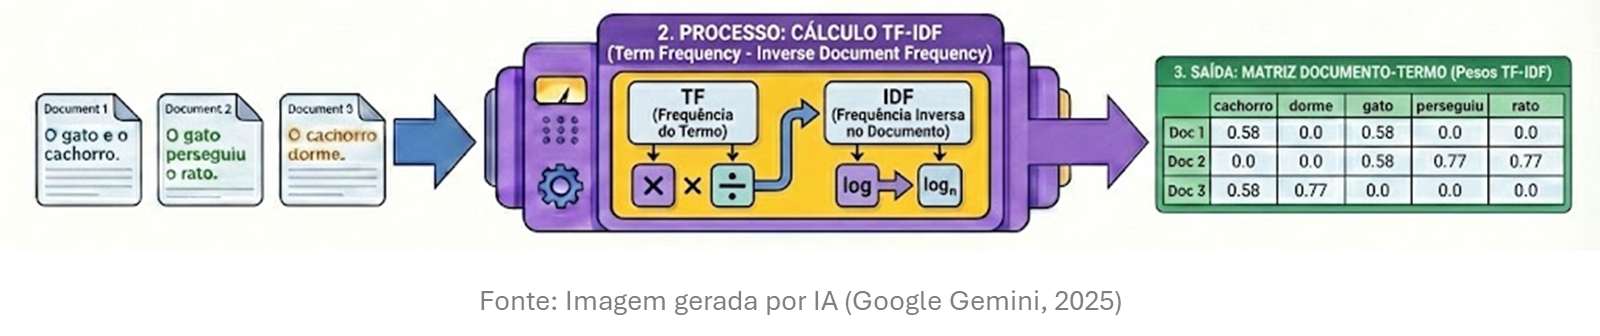

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vetor = TfidfVectorizer(lowercase=True, ngram_range=(1, 1))
vetor.fit(X)

X_train_vetor = vetor.transform(X_train)
X_test_vetor = vetor.transform(X_test)

pd.DataFrame(X_train_vetor.toarray(), columns=vetor.get_feature_names_out()).head(10)

,1985,19h,absolutamente,acessar,achei,adaptação,adorei,agendado,ajuda,amassada,...,uma,usar,uso,usuário,vezes,visita,vista,voltarei,voo,às
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.239996,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.350013,0.0,0.000000,0.000000,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.357453,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.389281,0.000000,0.0,0.389281,0.000000,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.208718,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.295501,0.0


### Treinar o modelo classificador

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vetor, y_train)


LogisticRegression(max_iter=1000, random_state=42)

### Testar o modelo em novos dados

Converter o texto para a representação vetorial numérica

In [ ]:
X_new = vetor.transform(['O atendimento ao cliente foi excepcional e resolveu meu problema rapidamente.'])
pd.DataFrame(X_new.toarray(), columns=vetor.get_feature_names_out()).head(10)

,1985,19h,absolutamente,acessar,achei,adaptação,adorei,agendado,ajuda,amassada,...,uma,usar,uso,usuário,vezes,visita,vista,voltarei,voo,às
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
model.predict(X_new)

array(['Positivo'], dtype='<U8')

### Avaliar modelo no conjunto de testes

In [ ]:
pd.DataFrame(X_test_vetor.toarray(), columns=vetor.get_feature_names_out()).head(10)

,1985,19h,absolutamente,acessar,achei,adaptação,adorei,agendado,ajuda,amassada,...,uma,usar,uso,usuário,vezes,visita,vista,voltarei,voo,às
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.361283,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.336002,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.299817,0.0,0.0,0.0,...,0.000000,0.336264,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.248344,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
y_test

['Neutro', 'Negativo', 'Neutro', 'Negativo', 'Positivo', 'Positivo']

In [ ]:
y_pred = model.predict(X_test_vetor)
y_pred.tolist()

['Positivo', 'Negativo', 'Positivo', 'Negativo', 'Negativo', 'Positivo']

In [ ]:
for frase, sentimento, predito in zip(X_test,y_test,y_pred):
    print(f'Frase: {frase:<80} - Sentimento: pred "{predito}" - real "{sentimento}"')


Frase: A bateria do celular dura o dia todo com uso moderado.                           - Sentimento: pred "Positivo" - real "Neutro"
Frase: Não gostei do final da série, achei que estragou toda a história.                - Sentimento: pred "Negativo" - real "Negativo"
Frase: Este documento contém as especificações técnicas do produto.                     - Sentimento: pred "Positivo" - real "Neutro"
Frase: O trânsito hoje estava simplesmente insuportável.                                - Sentimento: pred "Negativo" - real "Negativo"
Frase: Adorei a nova funcionalidade do aplicativo, ficou muito mais fácil de usar.      - Sentimento: pred "Negativo" - real "Positivo"
Frase: O show foi espetacular, uma energia contagiante do início ao fim.                - Sentimento: pred "Positivo" - real "Positivo"


Ver a taxa de acerto (acurácia)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.5

### Experimentar outros algoritmos classificadores

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=4),
    "Random Forest": RandomForestClassifier(random_state=4)
}

resultados = {}

# Treinar e avaliar cada modelo
for nome, clf in modelos.items():
    clf.fit(X_train_vetor, y_train)
    y_pred = clf.predict(X_test_vetor)
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc

for modelo, acc in resultados.items():
    print(f"{modelo}: {acc:.2f}")

Naive Bayes: 0.50
Logistic Regression: 0.50
Linear SVM: 0.50
Decision Tree: 0.50
Random Forest: 0.67


In [ ]:
clf = RandomForestClassifier(random_state=4)
clf.fit(X_train_vetor, y_train)
y_pred = clf.predict(X_test_vetor)
print(f'Taxa de acerto: {accuracy_score(y_test, y_pred)}\n')

for frase, sentimento, predito in zip(X_test,y_test,y_pred):
    print(f'Frase: {frase:<80} - Sentimento: pred "{predito}" - real "{sentimento}"')

Taxa de acerto: 0.6666666666666666

Frase: A bateria do celular dura o dia todo com uso moderado.                           - Sentimento: pred "Positivo" - real "Neutro"
Frase: Não gostei do final da série, achei que estragou toda a história.                - Sentimento: pred "Negativo" - real "Negativo"
Frase: Este documento contém as especificações técnicas do produto.                     - Sentimento: pred "Positivo" - real "Neutro"
Frase: O trânsito hoje estava simplesmente insuportável.                                - Sentimento: pred "Negativo" - real "Negativo"
Frase: Adorei a nova funcionalidade do aplicativo, ficou muito mais fácil de usar.      - Sentimento: pred "Positivo" - real "Positivo"
Frase: O show foi espetacular, uma energia contagiante do início ao fim.                - Sentimento: pred "Positivo" - real "Positivo"
